# Додаткове завдання до модуля 4: візуалізація даних.
В цьому ДЗ ми будемо багато працювати не тільки з візуалізаціями, а і з функціоналом pandas, адже візуалізація даних - це частина аналізу даних та працює спільно з агрегацією та фільтрацією наших даних. До того ж перед тим, як аналізувати дані, їх треба почистити. Чим ми і займемось.  

0.Імпортуйте бібліотеки matplotlib.pyplot, seaborn та pandas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Набір даних Taxis

Використовуючи метод з бібліотеки `seaborn` `load_dataset` ми завантажимо перший набір даних для аналізу. Завантажимо дані так, бо це зручно + аби ви знали, що є і така можливість знайти собі набір даних для експериментів.  
Набір даних містить поїздки таксі у Нью Йорку у 2019 році. Детальний опис на [сайті](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).  

Які колонки мість набір даних:  
- `pickup` - час початку поїздки  
- `dropoff` - час закінчення поїздки  
- `passengers` - кількість пасажирів у поїздці  
- `distance` - відстань поіздки  
- `fare` - базова плата за поїздку  
- `tip` - розмір чайових  
- `tolls` - плата за платні дороги (за це також платить пасажир)  
- `total` - сумарна плата за поїздку  
- `color` - колір авто, яке здійснювало поїздку  
- `payment` - метод оплати  
- `pickup_zone` - зона, у якій почалась поїздка  
- `dropoff_zone` - зона, у якій закінчилась поїздка  
- `pickup_borough` - район, у якому почалась поїздка  
- `dropoff_borough` - район, у якому закінчилась поїздка  

Назви ознак здбільшого говорять самі за себе. Слово borough перекладається з англійської як "район".

Ми будемо працювати сами з тим шматочком даних, які наявні в seaborn.  
Переглянути всі набори даних з seaborn можна [тут](https://github.com/mwaskom/seaborn-data).

Спершу - завантажуємо дані - просто виконайте клітинку нижче.

In [2]:
df_taxi = sns.load_dataset('taxis')

1.Виведіть
- перші 3 записи з набору даних
- типи даних в наборі даних df_taxi
- розміри набору даних

In [3]:
df_taxi.head(3)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan


In [4]:
df_taxi.dtypes

pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object

In [5]:
# розмір набору даних
df_taxi.shape

(6433, 14)

Очікуваний результат (можна вивести в окремих клітинках):

![](https://drive.google.com/uc?export=view&id=1rsgJvFEdXwGDTVl3CyyRL2ao8rzR_8P2)

2.Перевіримо, чи є в цьому наборі даних пропущені значення. Для цього можемо вивести кількість пропущених значень в кожній колонці наступним чином (це надзвичайно корисна команда, запамʼятайте її):

In [6]:
# пропущені значення
df_taxi.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Цікаво, чому дані відсутні? Відповідь на це питання нам дасть розуміння, чи можна такі дані видалити, чи можливо їх треба якось заповнити. Виведіть на екран ті рядки, де колонка, яка має найбільше пропущених значень (або одна з тих, що має максимальну кількість пропущених), має пропущені значення.
Подивіться на результат і напишіть свої думки щодо питань:
- чому на ваш погляд в цих рядках є відстуні дані в кількох колонках? Чому ви так думаєте?
- чому на ваш погляд є рядки з distance==0, а total!=0? Як ви до цього прйишли?
Відповідь просто текстом. Можна використовувати будь-які допоміжні операції над датасетом чи джерела, які допоможуть вам відповісти на ці питання. Якщо щось використовуєте, то це треба зазначити у відповіді.  

Ваша відповідь тут - це 70% виконання цього завдання.

In [7]:
# колонка де найбільше пропусків - вивести рядки де є NaN
df_taxi[df_taxi["dropoff_borough"].isna()].head(20)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.00,80.0,20.08,0.00,100.38,yellow,credit card,NaN,NaN,NaN,NaN
622,2019-03-12 19:52:36,2019-03-12 19:52:55,3,0.00,120.0,33.20,12.50,166.00,yellow,credit card,NaN,NaN,NaN,NaN
711,2019-03-21 17:39:50,2019-03-21 18:12:54,2,1.74,17.0,4.26,0.00,25.56,yellow,credit card,Midtown East,NaN,Manhattan,NaN
739,2019-03-14 00:09:17,2019-03-14 00:09:21,1,0.03,2.5,0.00,0.00,3.80,yellow,cash,Upper East Side South,NaN,Manhattan,NaN
970,2019-03-29 00:02:00,2019-03-29 00:02:05,2,0.00,45.0,5.00,0.00,50.30,yellow,credit card,NaN,NaN,NaN,NaN
1108,2019-03-10 09:33:13,2019-03-10 09:52:04,1,13.40,52.0,11.70,5.76,70.26,yellow,credit card,NaN,NaN,NaN,NaN
1112,2019-03-12 19:09:23,2019-03-12 19:20:46,1,0.90,8.5,1.92,0.00,14.72,yellow,credit card,Times Sq/Theatre District,NaN,Manhattan,NaN
1230,2019-03-29 07:52:46,2019-03-29 08:02:40,1,0.90,5.5,1.76,0.00,10.56,yellow,credit card,Yorkville East,NaN,Manhattan,NaN
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,1,0.00,72.0,0.00,0.00,72.00,yellow,NaN,East New York,NaN,Brooklyn,NaN
1787,2019-03-28 06:58:57,2019-03-28 07:18:10,1,6.32,20.5,4.26,0.00,25.56,yellow,credit card,Manhattan Valley,NaN,Manhattan,NaN


In [8]:
# перевірити payment==NaN
df_taxi[df_taxi['payment'].isna()].head(15)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
7,2019-03-22 12:47:13,2019-03-22 12:58:17,0,1.4,8.5,0.0,0.0,11.8,yellow,NaN,Murray Hill,Flatiron,Manhattan,Manhattan
445,2019-03-19 06:57:14,2019-03-19 07:00:08,1,1.3,5.5,0.0,0.0,6.3,yellow,NaN,Boerum Hill,Columbia Street,Brooklyn,Brooklyn
491,2019-03-07 07:11:33,2019-03-07 07:11:39,1,1.6,2.5,0.0,0.0,5.8,yellow,NaN,Murray Hill,Murray Hill,Manhattan,Manhattan
545,2019-03-27 11:03:43,2019-03-27 11:14:34,1,4.2,15.0,0.0,0.0,15.8,yellow,NaN,LaGuardia Airport,Forest Hills,Queens,Queens
621,2019-03-15 17:16:35,2019-03-15 17:25:01,1,1.3,7.5,0.0,0.0,11.8,yellow,NaN,Upper East Side North,Upper East Side South,Manhattan,Manhattan
770,2019-03-02 03:16:59,2019-03-02 03:17:06,0,9.4,2.5,0.0,0.0,3.8,yellow,NaN,JFK Airport,JFK Airport,Queens,Queens
913,2019-03-23 11:26:58,2019-03-23 11:35:17,2,1.3,7.5,0.0,0.0,10.8,yellow,NaN,Upper East Side South,Lincoln Square West,Manhattan,Manhattan
953,2019-03-08 02:58:37,2019-03-08 03:19:27,2,6.9,23.5,0.0,0.0,27.3,yellow,NaN,Garment District,Central Harlem North,Manhattan,Manhattan
1207,2019-03-08 15:41:20,2019-03-08 15:41:23,1,0.0,2.5,0.0,0.0,5.8,yellow,NaN,Hudson Sq,Hudson Sq,Manhattan,Manhattan
1372,2019-03-12 09:19:44,2019-03-12 09:43:09,1,1.6,14.5,0.0,0.0,17.8,yellow,NaN,Midtown East,Garment District,Manhattan,Manhattan


In [9]:
# перевірка зон

df_taxi[df_taxi['pickup_zone'].isna()]['pickup_borough'].value_counts()

Series([], Name: count, dtype: int64)

Як видно, NaN у payment та колонках із зонами трапляються в рядках, де distance = 0, passengers = 0, а тривалість поїздки становить лише кілька секунд. Це схоже на аномальні або незавершені поїздки.

Оскільки в таких записах total != 0, ймовірно, йдеться не про випадки, коли були певні нарахування попри відсутність фактичного маршруту: наприклад, плата за подачу авто, очікування або скасування.

Найбільше пропусків спостерігається в dropoff_zone та dropoff_borough. Додаткова перевірка показала, що коли pickup_zone відсутня, то pickup_borough також завжди відсутня. Це свідчить про те, що пропуски в географічних колонках виникають одночасно, тобто система не змогла визначити локацію загалом. Тому більш імовірно, що це пов’язано з технічною проблемою мапінгу або з неповними записами, а не з тим, що водій просто не зафіксував місце висадки.

3.Заповнимо пусті значення. Оскільки всі колонки набору даних мають пропущені значення в рядках з типом даних рядок, заповнимо пропущені значення рядком `NA`.
Створіть набір даних `df_taxi_clean`, який містить дані `df_taxi` із заповненими пропущеними значеннями у всіх колонках (де ті значення відсутні) значенням `NA`.

**УВАГА!** Надалі в роботі треба використовувати `df_taxi_clean`, ми ж його і створили для того, аби далі ним користуватись :)

In [10]:
# заповнити пропущені значення рядком "NA"

df_taxi_clean = df_taxi.fillna("NA")

Після виконання завдання запустіть наступну клітинку:

In [11]:
# перевірка

df_taxi_clean.isna().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=1G5_k_jmtNFFRdn7Kcw_fEoJyrkTeOGP4)

4.Хочеться подивитись на дані у динаміці. Перетворіть колонку `pickup` набору даних `df_taxi_clean` (нам нема чого працювати з "брудними" даними, якщо ми їх вже почистили, але хай будуть в окремій змінній про всяк випадок) у формат `datetime64[ns]`.
Якщо у Вас при завантаженні набору даних колонка `pickup`- вже в форматі `datetime64[ns]` - можете пропустити це завдання, або спробувати все ж таки написат функцію для трансформації.

Результат перетворення збережіть в тій самій колонці `pickup`.

In [12]:
# якщо  щось криве - не зламається а стане NaT

df_taxi_clean["pickup"] = pd.to_datetime(
    df_taxi_clean["pickup"],
    errors="coerce"
)

In [13]:
# перевірка

df_taxi_clean["pickup"].dtype

dtype('<M8[ns]')

Після виконання завдання запустіть наступну клітинку:

In [14]:
df_taxi_clean.pickup.head(3)

0   2019-03-23 20:21:09
1   2019-03-04 16:11:55
2   2019-03-27 17:53:01
Name: pickup, dtype: datetime64[ns]

Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=106hQKdEhLV3OIeFsP8yvXLo0cKk6Jmqo)

5.У нас колонка pickup зараз мість дані у форматі дата-час. Пропоную прибрати час і зробити аналітику по дням. Для цього виконайте клатинку нижче:

In [15]:
# прибрати час 

df_taxi_clean['pickup_day'] = df_taxi_clean.pickup.dt.floor('d')

А тепер згрупуйте дані по pickup_day та виведіть графік сумарних платежів по дням. УВАГА! Якщо хочете отримати підписи по осі ОХ як на прикладі, то графік необхідно будувати через `df.plot(...)`. Якщо у Вас будуть інші підписи осі ОХ - це ОК.

Після виведення графіку скажіть, чи бачите щось дивне на ньому? Важливо написати відповідь в цьому завданні словами.

In [16]:
# сумарні платежі по дням

daily_total = df_taxi_clean.groupby("pickup_day")["total"].sum()

<Axes: title={'center': 'Сумарні платежі по днях'}, xlabel='pickup_day'>

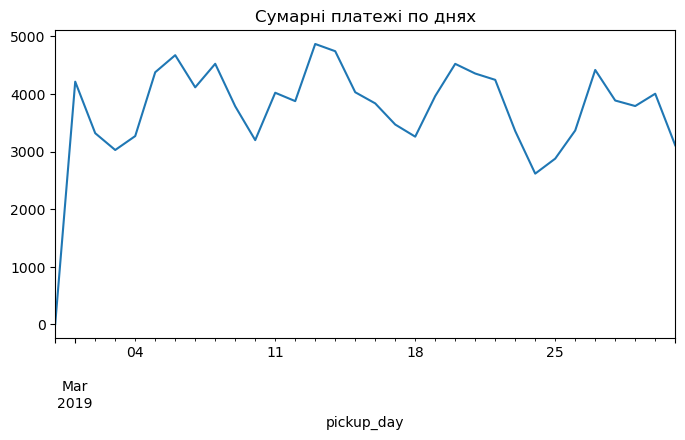

In [17]:
# графік "Сумарні платежі по днях"

daily_total.plot(figsize=(8, 4), title="Сумарні платежі по днях")

In [18]:
daily_total.head()

pickup_day
2019-02-28       6.30
2019-03-01    4213.83
2019-03-02    3319.02
2019-03-03    3027.32
2019-03-04    3269.08
Name: total, dtype: float64

Аномально низький показник на граіку відповідає даті pickup_day = 2019-02-28 із сумарною платою лише в 6.30, тоді як в усі інші дні оплата коливається  в межах від 3000 до 5000.
Можливо, цей запис є випадковим.


Приклад очікуваного графіку:

![](https://drive.google.com/uc?export=view&id=1t8yb_NNO2tfwDFDrBNl0BLJoYB0BsUK_)

6.Виведіть кількість рядків для кожного pickup_day.

In [19]:
# кількість рядків для кожного pickup_day

df_taxi_clean.groupby("pickup_day").size()

pickup_day
2019-02-28      1
2019-03-01    241
2019-03-02    198
2019-03-03    169
2019-03-04    171
2019-03-05    228
2019-03-06    257
2019-03-07    218
2019-03-08    235
2019-03-09    204
2019-03-10    185
2019-03-11    209
2019-03-12    218
2019-03-13    244
2019-03-14    260
2019-03-15    201
2019-03-16    220
2019-03-17    178
2019-03-18    173
2019-03-19    201
2019-03-20    233
2019-03-21    221
2019-03-22    229
2019-03-23    209
2019-03-24    149
2019-03-25    155
2019-03-26    178
2019-03-27    232
2019-03-28    205
2019-03-29    209
2019-03-30    215
2019-03-31    187
dtype: int64

Маєте побачити, що для дати 2019-02-28 є тільки один рядок. Це запис, який, схоже, потрапив сюди випадково, видаліть з набору даних df_taxi_clean рядок, що містить pickup_day рівний 2019-02-28. Та знову виведіть графік сумарних платежів по pickup_day.

In [20]:
# видалити pickup_day = 2019-02-28

df_taxi_clean = df_taxi_clean[
    df_taxi_clean["pickup_day"] != pd.to_datetime("2019-02-28")
]

<Axes: title={'center': 'Сумарні платежі по днях'}, xlabel='pickup_day'>

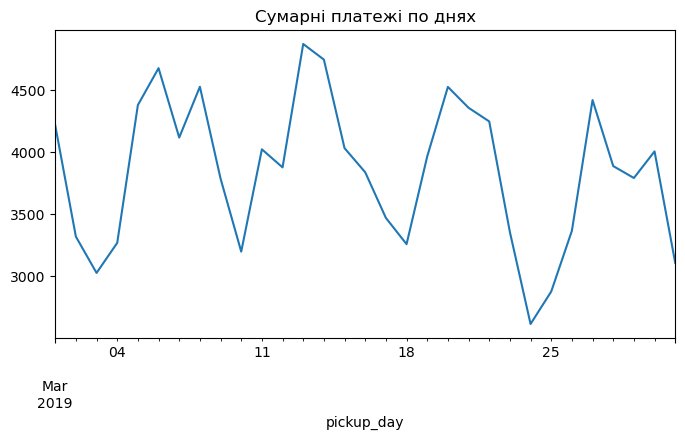

In [21]:

# оновлені платежі по дням
daily_total = df_taxi_clean.groupby("pickup_day")["total"].sum()

# оновлений графік
daily_total.plot(figsize=(8, 4), title="Сумарні платежі по днях")

Очікуваний графік:

![](https://drive.google.com/uc?export=view&id=1RfSjsgr5991dlz5bVbfXl8tCnUZhFJ8B)

7.Давайте подивимось на динаміку сумарних платежів по районам. Для цього сформуйте на основі `df_taxi_clean` зводну таблицю, де рядками є `pickup_day`, колонками `pickup_borough`, а значенням - сума платежів. Запишіть зводну таблицю в змінну `borough_pivot`. Наостанок, вилучіть колонку зі значенням `pickup_borough` рівним `NA` - уявімо, що ці дані нас не цікавлять.

In [22]:
# півот тейбл

borough_pivot = pd.pivot_table(
    df_taxi_clean,
    values="total",             # =платежі
    index="pickup_day",         # = дні
    columns="pickup_borough",   # =райони
    aggfunc="sum"               # = сумуємо
)

In [23]:
# видалити pickup_borough "NA"

borough_pivot = borough_pivot.drop(columns="NA")

Далі запустіть наступну клітинку та дайте відповідь на питання, в якому районі найчастіше найбільша сума денних платежів за поїздки на таксі?   
До речі, також рекомендую спробувати запустити команду `borough_pivot.plot()` та зрозуміти, навіщо нам тут частина `fillna(0)`.

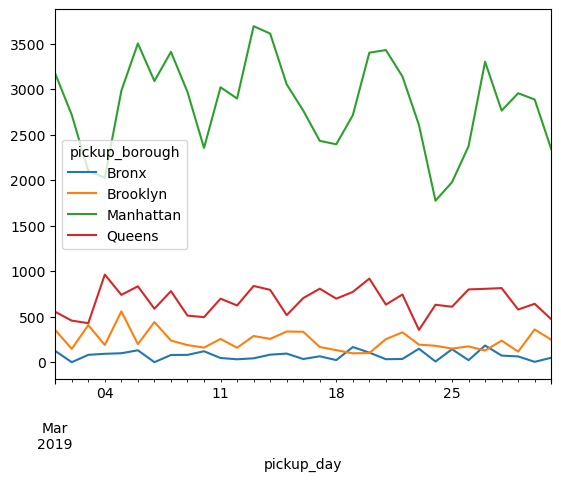

In [24]:
borough_pivot.fillna(0).plot();

Найбільша сума денних платежів спостерігається в районі Manhattan - зелена лінія значно вище за всі інші, стабільно близщько 2500–3700

<Axes: xlabel='pickup_day'>

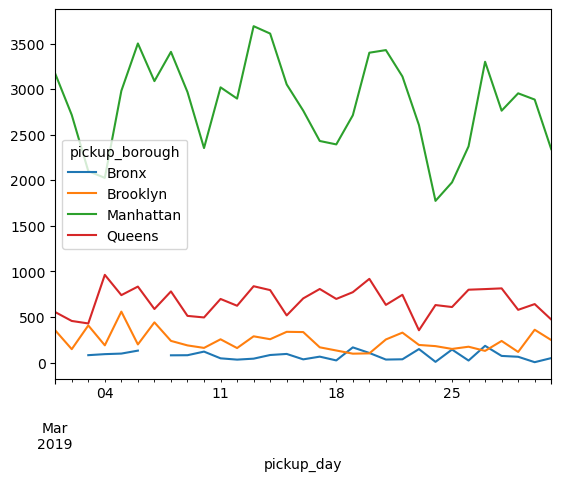

In [25]:
# порівняння

borough_pivot.plot()

Очікуваний графік :

![](https://drive.google.com/uc?export=view&id=1zhLnMdPCg54j2yzU1hRWv6wseSNPT1Oy)

8.Виведіть будь-яким способом гістограми суми денних платежів за поїздки по кожному з районів. Має бути 4 гістограми, на 4ох різних фігурах, або на одній.   

`Підказка:` Найпростіше це буде зробити, використавши `borough_pivot` та побудову графіку через `<назва датафрейму>.<назва графіку>()` - тобто методом датафрейму з пандаса. Але графік можна побудувати також використовуючи цикл. Для тих, хто хоче потренуватись, рекомендую зробити обома способами.

Пограйтесь з кількістю бінів. Яка кількість бінів на ваш погляд тут є вдалою? Чому?

array([[<Axes: title={'center': 'Bronx'}>,
        <Axes: title={'center': 'Brooklyn'}>],
       [<Axes: title={'center': 'Manhattan'}>,
        <Axes: title={'center': 'Queens'}>]], dtype=object)

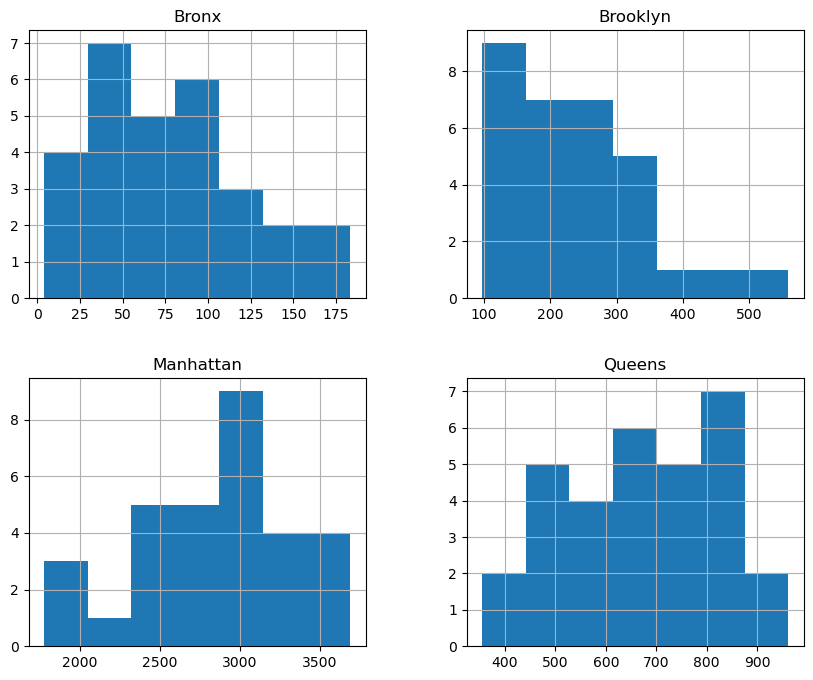

In [26]:
borough_pivot.hist(figsize=(10, 8), bins=7)


зупинилась на кількості бінів близько 6-7, оскільки вона дозволяє побачити форму розподілу без зайвого шуму. При меншій кількості бінів розподіл стає надто грубим, а при більшій -рваний, важче помітити загальну тенденцію.

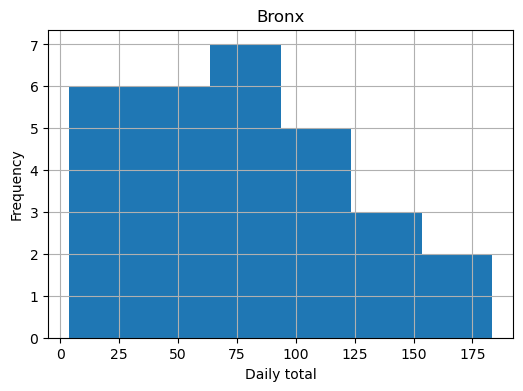

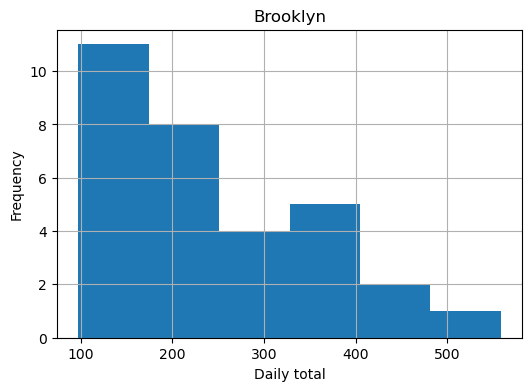

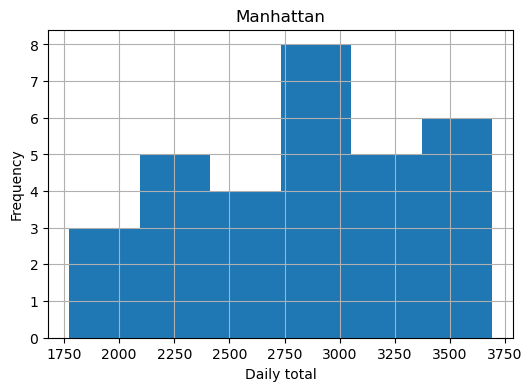

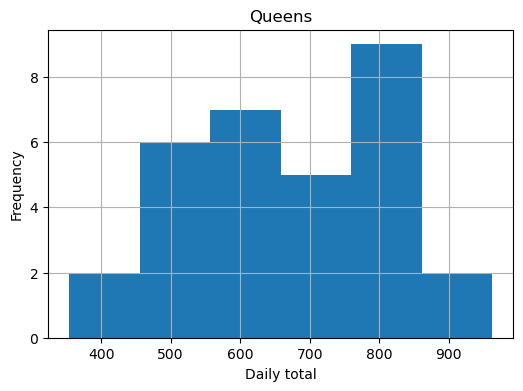

In [27]:
# через цикл

for col in borough_pivot.columns:
    plt.figure(figsize=(6, 4))
    borough_pivot[col].plot(kind="hist", bins=6, title=col)
    plt.xlabel("Daily total")
    plt.grid()
    plt.show()

Приклад одного з правильних виконань завдання:

![](https://drive.google.com/uc?export=view&id=1AfkIgwUAtaDiYoiK6NBOqCHBdUngRz4z)

9.Бачимо, що на окремих гістограмах у нас різні діапазони чеків. Припустимо, нам хочеться порівняти розподіли денних сум платежів по райнам. Давайте для цього виведемо 4 гістограми на одній фігурі. Вони звісно ж мають бути різного кольору і напівпрозорими для комфортного перегляду. Створіть гістограму максимально близьку до тої, що надана в очікуваному результаті.
`Підказка:` ця візуалізація створена з допомогою pandas plotting.

Text(0, 0.5, 'Count of rides')

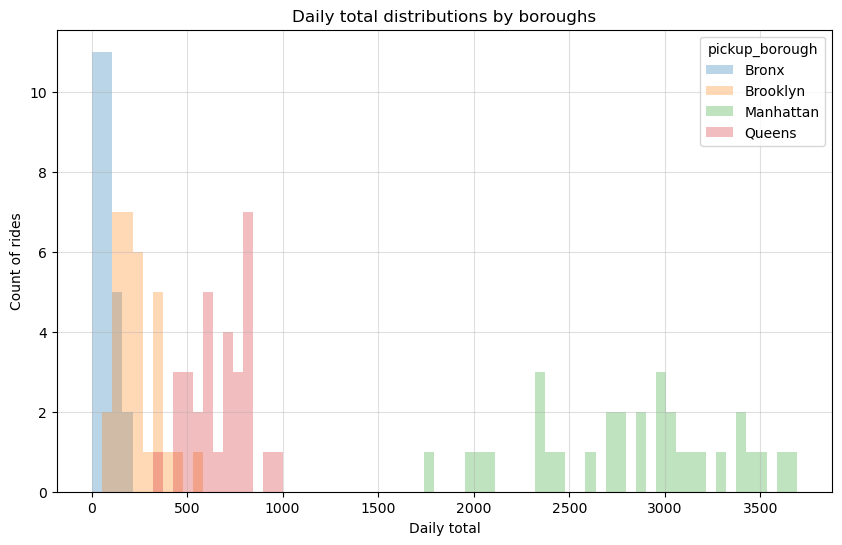

In [28]:
# 4 гістограми на 1 фігурі

ax = borough_pivot.plot(
    kind="hist",
    bins=70,
    alpha=0.3,
    figsize=(10, 6),
    title = "Daily total distributions by boroughs"
)
ax.grid(True, alpha=0.4)
ax.set_xlabel("Daily total")
ax.set_ylabel("Count of rides")

Якщо бінів замало, гістограми Bronx, Brooklyn і Queens злипаються в кілька великих стовпчиків і розподіл читається гірше. При більшій кількості бінів розподіли стають детальнішими і їх легше порівнювати.

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1J5PCLfVovNqeGxeeBGFUSS1Kqh6-UnwR)

А ось приклад, як можна було сформувати щось подібне з допомогою функціоналу seaborn. Як на мене візуалізація за замовчанням не є зручною для розуміння.  

`Опціональне завдання`: Пограйтесь з налаштуваннями і пошукайте варіант, за якого візуалізація розподілу суми денних платежів через seaborn є на ваш погляд зручною для аналізу.

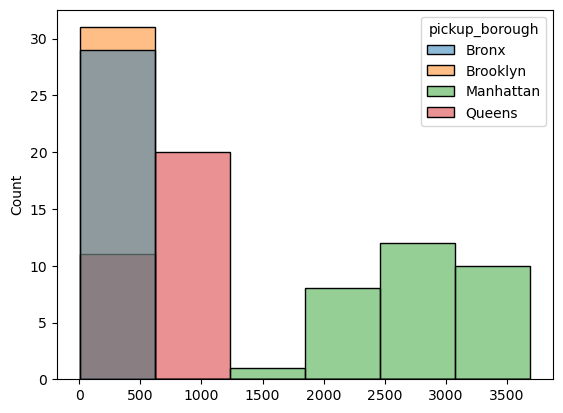

In [29]:
sns.histplot(data=borough_pivot, bins=6);

10.З допомогою seaborn виведіть гістограми суми щомісячних платежів по кольорам автомобілів (колонка `color`). На одній фігурі має бути кількість гістограм рівна кількості різних кольорів автомобілів в наборі даних. Встановіть розмір фігури (10,5) та знайдіть значення dots-per-inch для фігури за якого якість зображення буде хорошою (зображення не буде розмитим).
`Підказки:`
1. побудувати візуалізацію можна в один рядок коду, і ще один рядок - для встановлення розмірів і роздільної здатності фігури.
2. для зміни порядку відображення гістограм кольорів автомобілів (аби менша гістограма була перед, а не за більшою) можна посортувати датафрейм за полем кольору так, аби отримати той порядок, який вам потрібен.

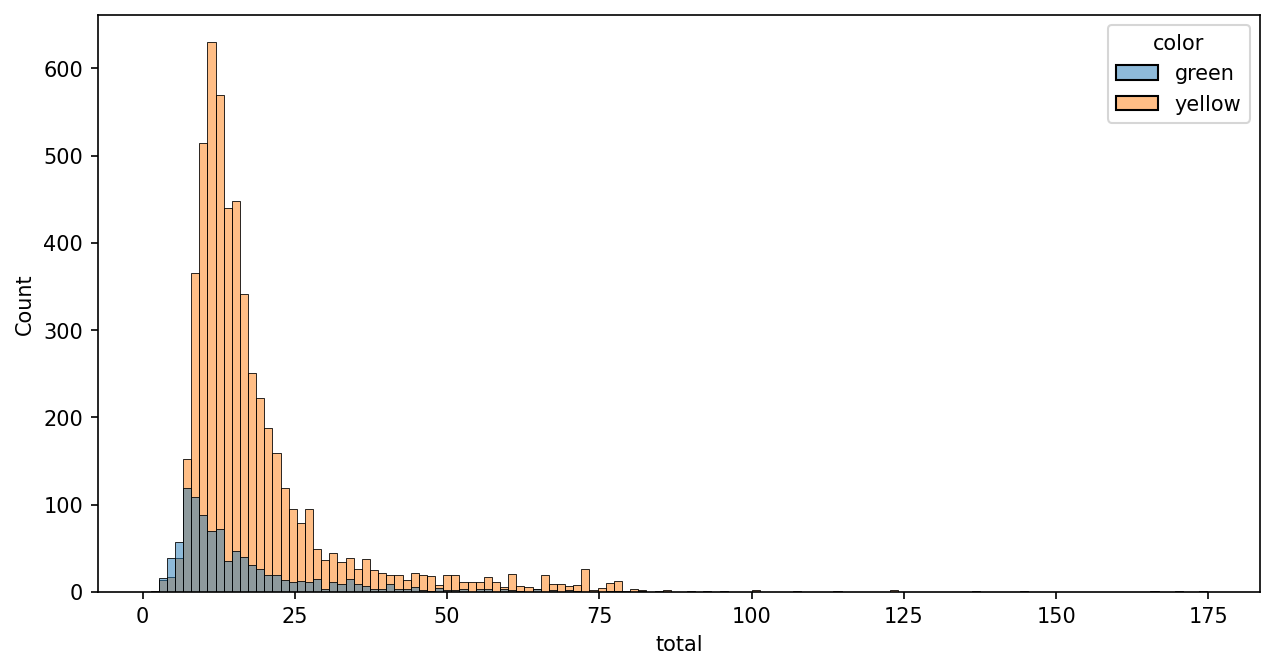

In [30]:
plt.figure(figsize=(10, 5), dpi=150)

sns.histplot(
    data=df_taxi_clean,
    x = "total",
    hue = "color",
    hue_order=[ "green", "yellow"],
    multiple="layer",
    bins=130)

plt.show();

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=17j9hUAo0-65yEuCMHOHUlEW0nRqePOrW)

11.Цікаво, а чи є залежність між дальністю поїздки і розміром чайових? Побудуйте діаграму розсіювання між дальністю поїздки і розміром чайових. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

В очікуваному результаті я надаю графік, який би будувала я. На наведеному прикладі найскладніша частина - це зробити червоною цю лінію тренду (вона побудована з допомогою спеціального типу графіку в seaborn). Аби вказати колір лінії в тому типу графіку треба зазначити в параметрі `line_kws`, що ми хочемо лінію червоного кольору. Але якщо у вас не буде виходити лінія червоного кольору - нехай буде синього - це не критично :)

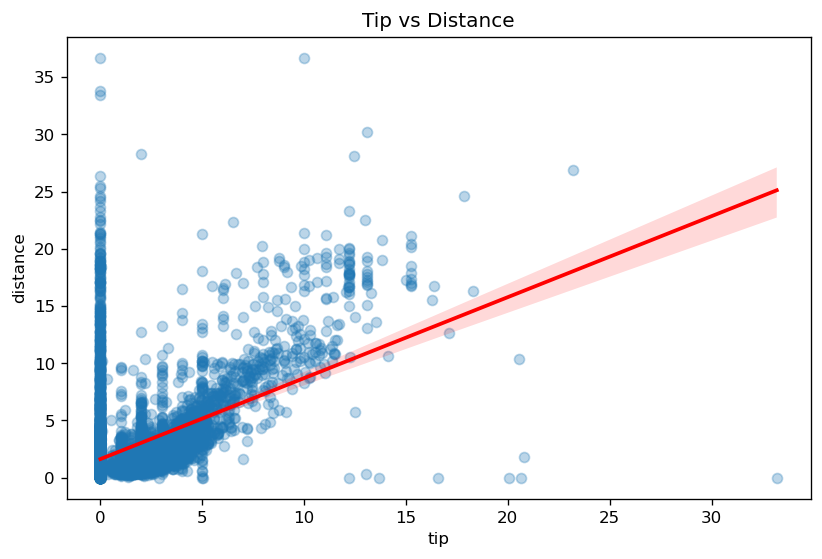

In [31]:
plt.figure(figsize=(8, 5), dpi =120)

sns.regplot(
    data=df_taxi_clean,
    x="tip",
    y="distance",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.xlabel("tip")
plt.ylabel("distance")
plt.title("Tip vs Distance")

plt.show()

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=19PtgLlPTJ1iR_AxcnBDZUw-U3Ulr6Cpy)

12.Дайте відповідь на питання: що означає пряма лінія з точок, паралельна осі, за якою розташована дальність поїздки?

In [32]:
# Показує що відсутність чайових зустрічається для поїздок різної дальності. Хоча загалом простежується залежність - 
# зі збільшенням дистанції зростають і чайові

13.Побудуйте поденну динаміку чайових по районам, в яких забрали пасажира. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати. Важливо, щоб на одному графіку було 4 лінії (всі райони, крім `NA`), які відображають динаміку чайових, була легенда і були підписи вісей. В очікуваному результаті я надаю графік, який би будувала я.

Дайте відповіді на питання:
- при початку поїздки в якому районі **найнижчий середній розмір** чайових?
- а в поїздках з якого району **найвищий середній розмір** чайових?
- при проїздках з його району розмір чайових найстабільніший (найменше змінюється з дня у день)?

In [39]:
# згрупувати

#tips_by_day = (
#    df_taxi_clean[df_taxi_clean["pickup_borough"] != "NA"]
#    .groupby(["pickup_day", "pickup_borough"])["tip"]
#    .mean()
#    .reset_index()
#)

/var/folders/0m/d7dfml251474rkrbbrrtw41h0000gn/T/ipykernel_2005/1980806931.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


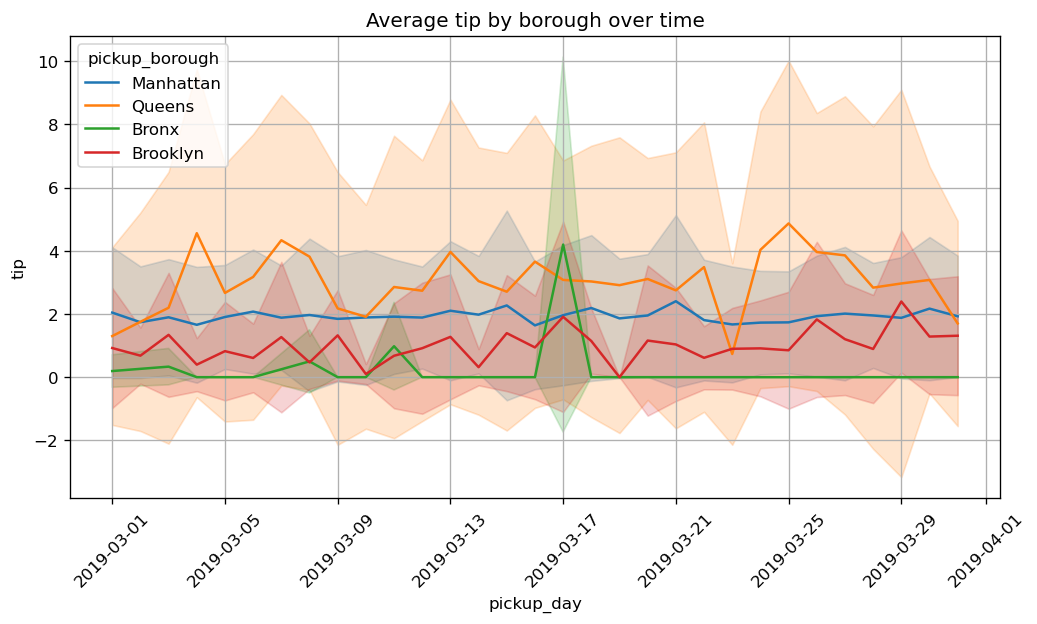

In [40]:
# графік

plt.figure(figsize=(10, 5), dpi=120)

sns.lineplot(
    data=df_taxi_clean[df_taxi_clean["pickup_borough"] != "NA"],
    x="pickup_day",
    y="tip",
    hue="pickup_borough",
    estimator='mean',
    ci='sd' 
)
plt.xlabel("pickup_day")
plt.ylabel("tip")
plt.title("Average tip by borough over time")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

1) при початку поїздки в якому районі **найнижчий середній розмір** чайових?

середні чайові в Бронксі майже завжди ≈ 0 (блакитна лінія)

2) а в поїздках з якого району **найвищий середній розмір** чайових?

найвищі чайові зустрічаються у Квінсі (червона лінія)

3) при проїздках з його району розмір чайових найстабільніший (найменше змінюється з дня у день)?

розмір чайових майже не змінюється на Мангеттені (зелена лінія)

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=1yoEqYwNwyQmTTrkk_Mz6D-ruAvE-Sx8q)

14.Побудуйте box-plot розміру чайових по району (всі райони, крім `NA`) старту поїздки. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

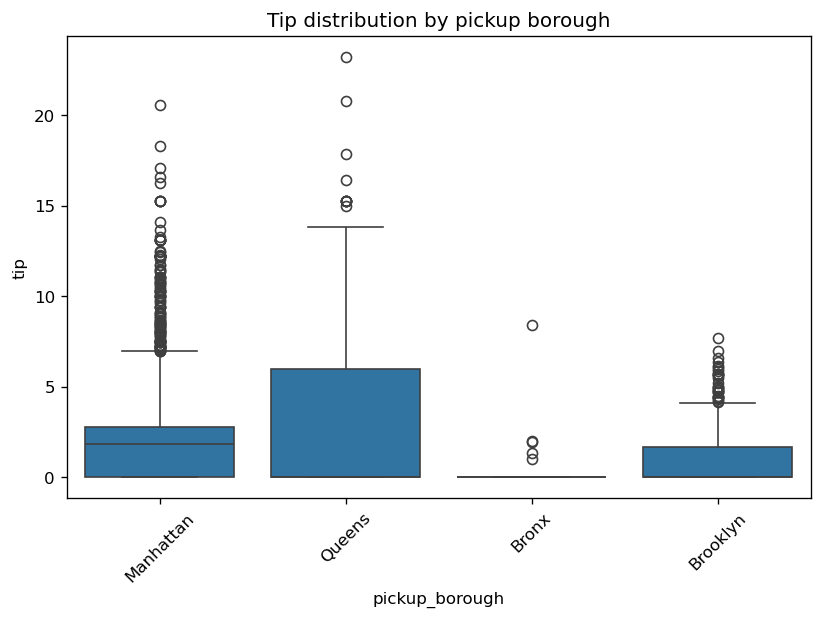

In [41]:
plt.figure(figsize=(8, 5), dpi=120)

sns.boxplot(
    data=df_taxi_clean[df_taxi_clean["pickup_borough"] != "NA"],
    x="pickup_borough",
    y="tip"
)

plt.xlabel("pickup_borough")
plt.ylabel("tip")
plt.title("Tip distribution by pickup borough")
plt.xticks(rotation=45)

plt.show()

найбільші викиди бачимо для Мангеттену та Квінсу - там частіше трапляються поїздки з великими чайовими.

В Бронксі типові чайові є найнижчими. 

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=1o6dFRTSj0gLQ_DMWeb7upqvuPNsL0MQc)

15.Творче завдання. Створіть ТРИ інформативних візуалізації, які б допомогли в аналізі цих даних.   

Що вам було б цікаво дізнатись про ці поїздки? Як це можна було б використати при прийнятті рішень бізнесом?
Наприклад, якщо найбільше поїздок в певний час доби, значить, треба стимулювати водіїв працювати в ці години. Якщо найбільше поїздок з певного району - треба тримати там запас авто, які б могли взяти пасажирів і т.д.
Не обмежуйте свою фантазію.

Візуалізації мають бути не тими, на які ми вже побудували вище. Але можна створювати аналогічні, просто з використанням інших полів даних. І описати, що ви бачите з тих візуалізацій.
Без виконання цього завдання ДЗ не приймаєтья. Якщо є питання щодо виконання - пишіть у чат.

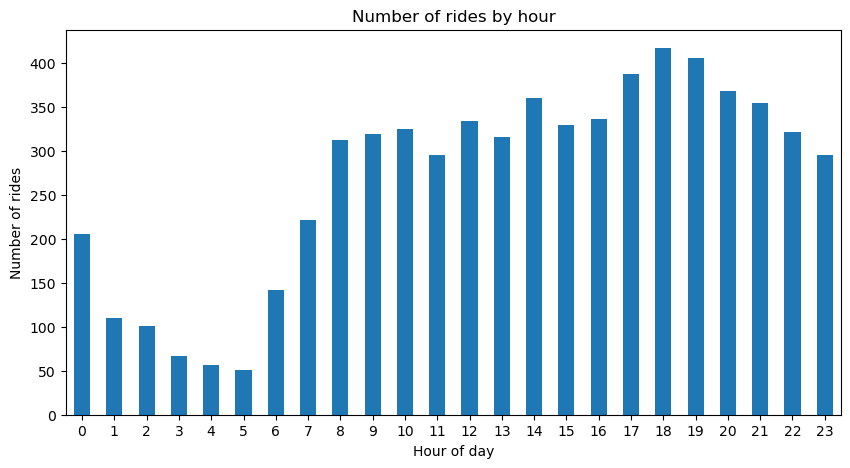

In [42]:
# 1. коли найбільший попит

df_taxi_clean["pickup_hour"] = df_taxi_clean["pickup"].dt.hour

rides_by_hour = df_taxi_clean.groupby("pickup_hour").size()

rides_by_hour.plot(kind="bar", figsize=(10, 5), title="Number of rides by hour")
plt.xlabel("Hour of day")
plt.ylabel("Number of rides")
plt.xticks(rotation=0)
           
plt.show()

Бачимо найменший попит у нічні години, після півночі і до 6ї ранку. Тому вночі не варто марно  тримати запас водіїв. Штучно підвищити попит в цей час мабуть не вийде, навіть запровадивши акції. Це скоріше норма яка не потребує корекції.

Мінімум припадає на 5 ранку.

Максимум припадає на 18 годину.

Найбільш гарячі години - 17, 18, 19. Саме в цей час доцільно залучити додаткові авто. Також логічно мати підвищений тариф на поїзки в ці пікові години.

Але вцілому протягом дня попит є доволі стабільно високим.



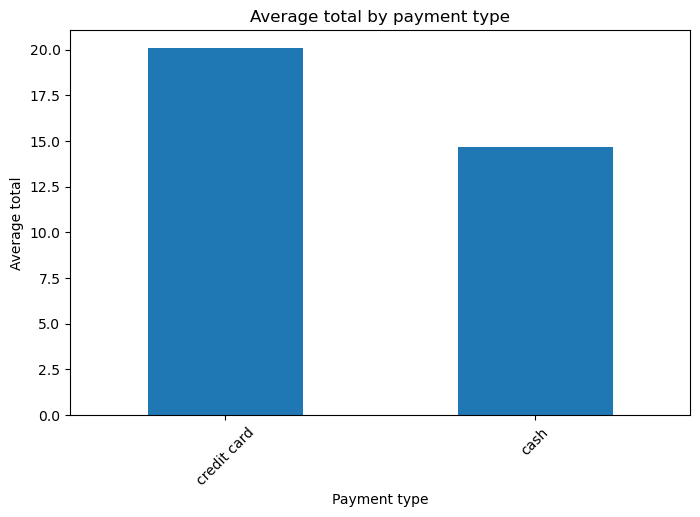

In [43]:
# 2. порівняти середній чек між cash і credit card

avg_total_by_payment = (
    df_taxi_clean[df_taxi_clean["payment"] != "NA"]
    .groupby("payment")["total"]
    .mean()
    .sort_values(ascending=False)
)

avg_total_by_payment.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average total by payment type")

plt.xlabel("Payment type")
plt.ylabel("Average total")
plt.xticks(rotation=45)

plt.show()

Середній розмір платежів зроблених картою - більший, аніж поїздки оплачені готівкою.
Тобто, пасажири, які платять картою частіше здійснюють довші (чи дорожчі) поїзки. Можливо вони і більш схильні лишати чайові. 

Стимулявання безготівкових розрахунків може сприяти подальшому зростанню середнього чеку.

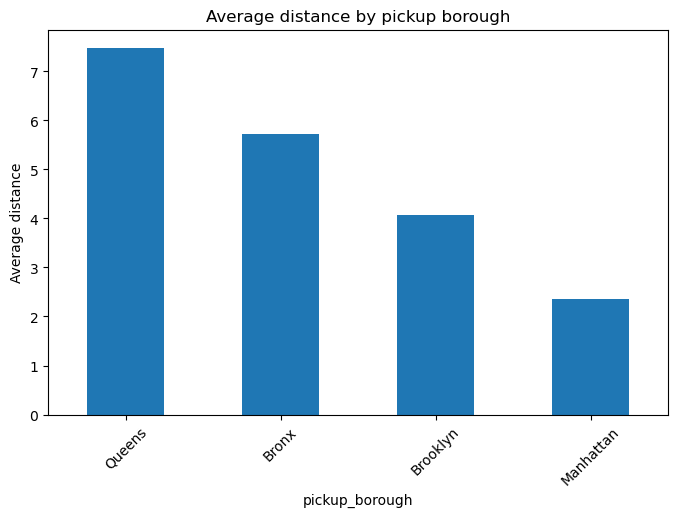

In [44]:
# 3. звідки поїзки довші/коротші

avg_distance_by_borough = (
    df_taxi_clean[df_taxi_clean["pickup_borough"] != "NA"]
    .groupby("pickup_borough")["distance"]
    .mean()
    .sort_values(ascending=False)
)

avg_distance_by_borough.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average distance by pickup borough"
)

plt.xlabel("pickup_borough")
plt.ylabel("Average distance")
plt.xticks(rotation=45)

plt.show()

Найдовші поїзки відбуваються з Квінсу. Мабуть звідси частіше прямують в інші райони, тому доввжина поїздок більша.

Найкоротші з Мангеттену. Можливо через високу щільність можливих пунктів призначення. Скоріше це поїздки бізнес-характеру, апоінтменти.

Ця візуалізація допоможе ефективніше планувати час водіїв, розуміти потенційний дохід.

Водії у Квінсі чи Бронксі зможуть заробити більше за рахунок довгих поїздок. Але працюючи в Мангеттені - ймовірніше отримають більші чайові.